<a href="https://colab.research.google.com/github/gibranfp/CursoAprendizajeProfundo/blob/2027-1/notebooks/1d_redes_densas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regresión con redes densas en PyTorch
Para facilitar la definición, entrenamiento e inferencia de redes neuronales profundas con diversas arquitecturas y tipos de capas, PyTorch provee clases y funciones a distintos niveles de abstracción. En esta libreta revisaremos las interfaces principales.

![](https://manalelaidouni.github.io/assets/img/pexels/Pytorch-package-hierarchy.jpg)

Fuente: [https://manalelaidouni.github.io/Pytorch%20guide%20101.html](https://manalelaidouni.github.io/Pytorch%20guide%20101.html)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch as th
from torch import nn

# fijamos las semillas de los PRNG por reproducibilidad
np.random.seed(42)
th.manual_seed(42)

T_LOTE = 8

## Conjunto de datos
Usaremos el conjunto de datos de regresión Diabetes Dataset que se puede obtener con scikit-learn. Este conjunto de datos está compuesto por 442 ejemplos con 10 atributos numéricos y una variable de respuesta.

In [2]:
from sklearn.datasets import load_diabetes

db = load_diabetes(return_X_y=False, as_frame=True)

Revisamos la descripción del conjunto:

In [3]:
print(db.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

Desplegamos los datos:

In [4]:
db['data']

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641
...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930


Exploramos la distribución de los valores de la variable objetivo:

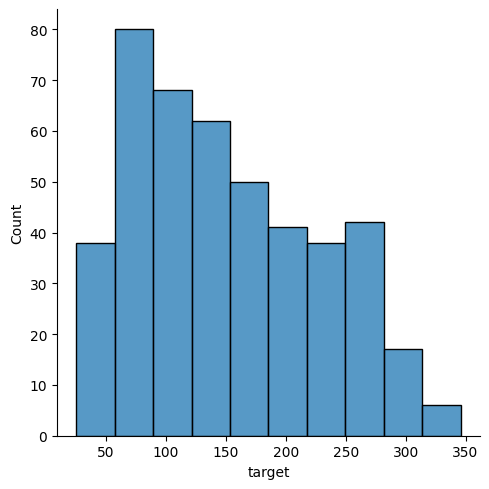

In [5]:
import seaborn as sns

sns.displot(db['target'])
plt.show()

Dividimos este conjunto en subconjuntos de entrenamiento, validación y prueba usando la función `train_test_split` de scikit-learn.

In [6]:
from sklearn.model_selection import train_test_split

X = db['data'].to_numpy()
y = db['target'].to_numpy()

# Dividimos el conjunto completo en subconjuntos de entrenamiento y prueba
X_ent, X_prueba, y_ent, y_prueba = train_test_split(X,
                                                    y,
                                                    test_size=0.3,
                                                    shuffle=True,
                                                    random_state=42)

# Dividimos entrenamiento en subconjuntos de entrenamiento y validación
X_ent, X_val, y_ent, y_val = train_test_split(X_ent,
                                              y_ent,
                                              test_size = 0.2,
                                              shuffle=True,
                                              random_state=42)

# Desplegamos las formas de los subconjuntos
print(f'Forma de X_ent = {X_ent.shape}, y_ent = {y_ent.shape}')
print(f'Forma de X_val = {X_val.shape}, y_val = {y_val.shape}')
print(f'Forma de X_prueba = {X_prueba.shape}, y_prueba = {y_prueba.shape}')

Forma de X_ent = (247, 10), y_ent = (247,)
Forma de X_val = (62, 10), y_val = (62,)
Forma de X_prueba = (133, 10), y_prueba = (133,)


Es importante asegurarse de que las formas de los tensores de las predicciones (`y_hat`) y de las salidas reales (`y`) sean iguales. Aquí vamos a presuponer que son vectores columnas de $n \times 1$, por lo que cambiamos de forma.

In [7]:
y_ent = y_ent.reshape((y_ent.shape[0], 1))
y_val = y_val.reshape((y_val.shape[0], 1))
y_prueba = y_prueba.reshape((y_prueba.shape[0], 1))

print(f'Forma de y_ent = {y_ent.shape}, y_val = {y_val.shape}, y_prueba = {y_prueba.shape}')

Forma de y_ent = (247, 1), y_val = (62, 1), y_prueba = (133, 1)


Se ajusta el estandarizador únicamente con el subconjunto de entrenamiento y se aplica a entrenamiento y validación. El subconjunto de prueba se aparta desde el inicio y no se usa en esta libreta. Se reserva para evaluar el modelo una sola vez, después de haber elegido la arquitectura y los hiperparámetros con el subconjunto de validación.

In [8]:
from sklearn.preprocessing import StandardScaler

sc_atr = StandardScaler()
sc_atr.fit(X_ent)
X_ent = sc_atr.transform(X_ent)
X_val = sc_atr.transform(X_val)

Convertimos los subconjuntos de arreglos de NumPy a instancias de `Tensor` de PyTorch y los cargamos a la GPU (si está disponible). Para evitar errores de tipos de datos distintos de los operandos, es importante asegurarse de que coincidan. En esta libreta vamos a trabajar con flotantes de 32 bits, por lo que lo especificamos en la función `tensor`.

In [9]:
disp = 'cuda:0' if th.cuda.is_available() else 'cpu'

X_ent = th.tensor(X_ent, dtype = th.float32, device = disp)
X_val = th.tensor(X_val, dtype = th.float32, device = disp)

y_ent = th.tensor(y_ent,  dtype = th.float32, device = disp)
y_val = th.tensor(y_val,  dtype = th.float32, device = disp)

print(f'Forma de X_ent = {X_ent.shape}, y_ent = {y_ent.shape}')
print(f'Forma de X_val = {X_val.shape}, y_val = {y_val.shape}')

Forma de X_ent = torch.Size([247, 10]), y_ent = torch.Size([247, 1])
Forma de X_val = torch.Size([62, 10]), y_val = torch.Size([62, 1])


Creamos nuestro cargador de datos a partir de los tensores mediante la clase `TensorDataset`.

In [10]:
from torch.utils.data import TensorDataset, DataLoader

entdl = DataLoader(TensorDataset(X_ent, y_ent),
                   batch_size=T_LOTE,
                   shuffle=True,
                   drop_last=True)
valdl = DataLoader(TensorDataset(X_val, y_val),
                   batch_size=T_LOTE,
                   shuffle=False,
                   drop_last=False)

## Clase `Module` de `nn`
Muchas de las clases y funciones para definir, entrenar y evaluar redes neuronales están contenidas el módulo `nn` de PyTorch. En particular contamos con la clase [`Module`](https://pytorch.org/docs/stable/generated/torch.nn.Module.html), una plantilla base para definir los distintos componentes de una arquitectura de red (ver [https://pytorch.org/docs/stable/notes/modules.htm](https://pytorch.org/docs/stable/notes/modules.html)). De hecho, hay varias subclases predefinidas de `Module` asociadas a diversos tipos de capas. Por ej., la subclase [`Linear`](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html) representa una capa densa o completamente conectada. Esta subclase tiene como argumentos no opcionales la dimensión de los vectores de entrada y el número de neuronas (dimensión de los vectores de salida). Una instancia de `Linear` procesa una matriz de tamaño $n \times \texttt{in_features}$, la cual multiplica por la transpuesta de una matriz de pesos de $\texttt{out_features} \times \texttt{in_features}$ y le suma un vector de sesgos de tamaño $\texttt{out_features}$

In [11]:
clin = nn.Linear(in_features = X_ent.shape[-1], # dimensión de entradas
                 out_features = 1, # número de neuronas (dimensión de salidas)
                 bias = True) # si usar sesgo o no

Podemos especificar que se cree directamente una instancia de cualquier subclase de `Module` en el CPU o en el GPU pasando el argumento `device=nombre_del_dispositivo` al constructor. También podemos mover una instancia ya creada de un dispositivo a otro con el método `to(nombre_del_dispositivo)`. Movemos la instancia de `Linear` a la GPU.

In [12]:
clin.to(disp)

Linear(in_features=10, out_features=1, bias=True)

Obtenemos la salida de la capa para el conjunto de datos de entrenamiento mediante el operador de paréntesis.

In [13]:
y_pred = clin(X_ent)
y_pred.shape

torch.Size([247, 1])

Para definir una nueva capa, un nuevo bloque o una red debemos crear una subclase de `Module` y especificar como mínimo los métodos:
- `__init__`, que es el constructor de la subclase y en el cual se tiene que llamar al constructor de la clase base `Module` mediante la función `super` de Python.
- `forward`, que define lo que se ejecuta al llamar al operador paréntesis en una instancia de dicha clase.

Por ej. para crear nuestra propia capa densa en el método `__init__` (constructor) recibiríamos la dimensión de las entradas y el número de neuronas (dimensión de las salidas) e instanciaríamos la matriz de pesos $\mathbf{W} \in \mathbb{R}^{k \times d}$ y el vector de sesgos $\mathbf{b} \in \mathbb{R}^{k}$. En el método `forward` se esperaría una matriz de $\mathbf{X} \in \mathbb{R}^{n \times d}$ como entrada y se realizaría la operación $\mathbf{X} \mathbf{W}^{\top} + \mathbf{b}$.

In [14]:
class MiLinear(nn.Module):
  # En el constructor recibimos la dimensión de las entradas y la de las salidas
  # e instanciamos la matriz de pesos W y el vector de sesgos b inicializándolos
  # con números aleatorios y ceros, respectivamente.
  def __init__(self, d, k):
    super().__init__()

    self.d = d
    self.k = k
    self.W = nn.Parameter(th.normal(size = (k, d), mean = 0, std = 0.1))
    self.b = nn.Parameter(th.zeros(k, dtype = th.float32))

  # En este método se define el comportamiento del operador paréntesis. Al ser
  # una capa densa, se espera recibir una matriz X de (n, d) y se realizaría
  # la operación de multiplicación de X con la transpuesta de la matriz de
  # pesos W de (k, d) y se sumaría el vector de sesgos b de (k,)
  def forward(self, x):
    return x @ self.W.T + self.b

  def extra_repr(self):
    return f'd={self.d}, k={self.k}'

Instanciamos la subclase de nuestra capa densa, la movemos a la GPU y pasamos el conjunto de entrenamiento.

In [15]:
milin = MiLinear(X_ent.shape[-1], 1)
milin.to(disp)

print(f'Instancia de {milin} con forma = {milin(X_ent).shape}')

Instancia de MiLinear(d=10, k=1) con forma = torch.Size([247, 1])


## Clases y funciones para optimizadores
Para facilitar el entrenamiento de los modelos vamos a definir una función para un paso de entrenamiento, a la cual llamaremos `paso_ent`. Esta función recibe como argumento:
- El modelo como una instancia de `Module` (`modelo`).
- La función de pérdida (`fp`).
- Una instancia de `Optimizer` del módulo `optim` de PyTorch para actualizar los pesos y sesgos (`opt`).
- Una instancia de `Tensor` con el lote de entradas (`X`).
- Una instancia de `Tensor` con el lote de salidas (`y`).

La función obtiene las predicciones del modelo para las entradas, calcula la pérdida, obtiene los gradientes y actualiza todos los parámetros del modelo mediante descenso por gradiente.

In [16]:
from torch.optim import SGD

def paso_ent(modelo, fp, opt, X, y):
  opt.zero_grad() # se ponen los gradientes asociados a los parámetros
                  # a actualizar en cero
  y_hat = modelo(X) # se propagan las entradas para obtener las predicciones
  perdida = fp(y_hat, y) # se calcula la pérdida
  perdida.backward() # se obtienen los gradientes
  opt.step() # se actualizan todos los parámetros del modelo


  perdida_paso = perdida.detach().item() # convertimos la pérdida a un
                                         # flotante de Python
  return perdida_paso

También definimos una función para el ciclo de entrenamiento principal, que llamaremos `entrena`. Esta función recibe como argumentos:
- El modelo como una instancia de `Module` (`modelo`).
- La función de pérdida (`fp`).
- La métrica de evaluación (`metrica`).
- Una instancia de `Optimizer` del módulo `optim` de PyTorch para actualizar los pesos y sesgos (`opt`).
- El cargador de datos del subconjunto de entrenamiento (`entdl`).
- El cargador de datos del subconjunto de validación (`valdl`).
- El número de épocas de entrenamiento (`n_epocas`).

Para cada una de las épocas, va tomando un lote de entradas y salidas a la vez, con los cuales se realiza un paso de entrenamiento.

In [17]:
def entrena(modelo, fp, metrica, opt, entdl, valdl, n_epocas = 100):

  hist = {'perdida_ent': np.zeros(n_epocas, dtype = np.float32),
          'perdida_val': np.zeros(n_epocas, dtype = np.float32)}

  for e in range(n_epocas):
    # bucle de entrenamiento
    modelo.train()
    n_ej_ent = 0
    for Xlote, ylote in entdl:
      hist['perdida_ent'][e] += paso_ent(modelo, fp, opt, Xlote, ylote) * ylote.shape[0]
      n_ej_ent += ylote.shape[0]

    # bucle de evaluación
    modelo.eval()
    n_ej_val = 0
    for (Xlote, ylote) in valdl:
      with th.no_grad():
        y_pred = modelo(Xlote)
        hist['perdida_val'][e] += metrica(y_pred, ylote).cpu().numpy() * ylote.shape[0]
        n_ej_val += ylote.shape[0]

    hist['perdida_ent'][e] /= n_ej_ent
    hist['perdida_val'][e] /= n_ej_val

  return hist

Como función de pérdida emplearemos el error cuadrático medio (ECM) definido como

$$
\mathcal{L}(\mathbf{\hat{y}}, \mathbf{y}) = \frac{1}{n}\sum_{i=1}^n (\hat{y}^{(i)} - y^{(i)})^2
$$

PyTorch incluye varias funciones de pérdida predefinidas dentro del submódulo `functional` del módulo `nn`, además de clases que envuelven estas funciones, cuyas instancias se conocen como criterios. Por ej. la función `mse_loss` de `functional` define el ECM y la clase `MSELoss` de `nn` es su correspondiente criterio. Movemos la instancia de nuestra capa densa a la GPU, creamos el criterio de ECM instanciando la clase `MSELoss`, entrenamos nuestro modelo de regresión lineal y graficamos la pérdida.

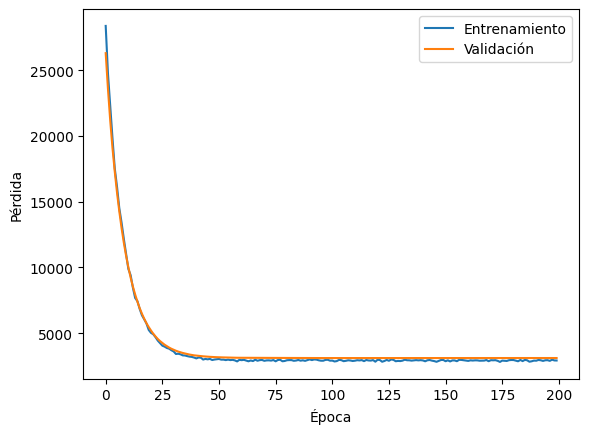

In [18]:
milin.to(disp)

ecm = nn.MSELoss()
opt = SGD(milin.parameters(), lr = 1e-3)
hist = entrena(milin, ecm, nn.functional.mse_loss, opt, entdl, valdl, n_epocas=200)

plt.plot(hist['perdida_ent'], label='Entrenamiento')
plt.plot(hist['perdida_val'], label='Validación')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.show()

Usando la clase base `Optimizer` se pueden definir diferentes algoritmos de optimización para entrenar modelos con la misma interfaz general. Esto ofrece la flexibilidad de cambiar entre algoritmos simplemente instanciando la clase del optimizador de interés y pasándolo como argumento. Incluso es posible definir un algoritmo propio generando una subclase de `Optimizer` y especificando los métodos:
- `__init__`: El constructor de la clase, el cual recibe como argumento los parámetros a optimizar (`params`) como iterable. En este método se llama al constructor de la súperclase mediante la función `super`.
- `step`: Especifica la regla con la que se actualizan los parámetros pasados como argumento al constructor usando los gradientes obtenidos al llamar `.backward` (almacenados en el elemento `grad` de la instancia de `Parameter`). Este método no recibe argumentos.

In [19]:
class MiSGD(th.optim.Optimizer):
  def __init__(self, params, lr = 1e-3):
    # lr debe ser mayor a 0
    assert lr > 0

    super().__init__(params, defaults = {'lr': lr})

  def step(self, closure=None):
    with th.no_grad():
      for g in self.param_groups:
        for p in g['params']:
          if p.grad is not None:
            p.add_(p.grad, alpha=-g['lr'])

Instanciamos y entrenamos un modelo de regresión lineal con este optimizador y graficamos la pérdida.

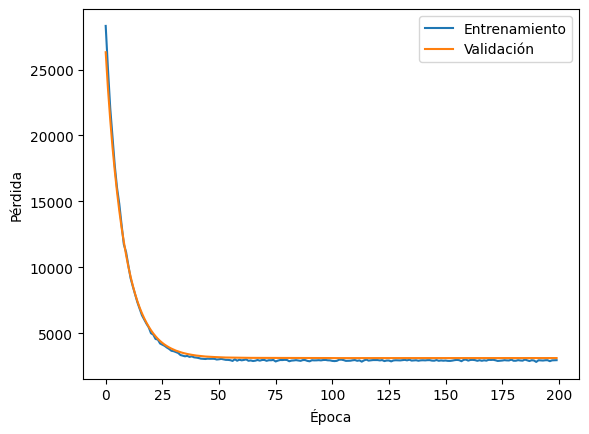

In [20]:
milin = MiLinear(X_ent.shape[-1], 1)
milin.to(disp)
ecm = nn.MSELoss()
opt = MiSGD(milin.parameters(), lr = 1e-3)
hist = entrena(milin, ecm, nn.functional.mse_loss, opt, entdl, valdl, n_epocas=200)

plt.plot(hist['perdida_ent'], label='Entrenamiento')
plt.plot(hist['perdida_val'], label='Validación')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.show()

## Contenedor `Sequential`
`Sequential` es un contenedor que permite generar una subclase de `Module` a través de una lista o tupla de capas predefinidas que se conectan de manera secuencial (la salida de una capa es la entrada de la siguiente). Por ej. para definir una red densa o completamente conectada con dos capas ocultas y una de salida:

In [21]:
modelo = nn.Sequential(nn.Linear(X_ent.shape[-1], 20),
                       nn.Sigmoid(),
                       nn.Linear(20,30),
                       nn.Sigmoid(),
                       nn.Linear(30, 1))

Movemos nuestra red a la GPU, creamos el criterio de ECM, instanciamos el optimizador, entrenamos y graficamos la pérdida.

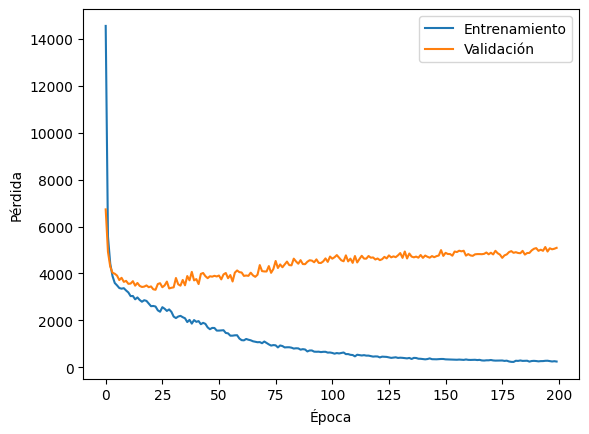

In [22]:
modelo.to(disp)
ecm = nn.MSELoss()
opt = SGD(modelo.parameters(), lr = 1e-3)
hist = entrena(modelo, ecm, nn.functional.mse_loss, opt,
               entdl, valdl, n_epocas=200)

plt.plot(hist['perdida_ent'], label='Entrenamiento')
plt.plot(hist['perdida_val'], label='Validación')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.show()

## Definición mediante subclase
Esta misma red podemos especificarla definiendo una subclase de `Module` como:

In [23]:
class MiMLP(nn.Module):
  def __init__(self, d_ent):
    super().__init__()

    self.c1 = nn.Linear(d_ent, 20)
    self.c2 = nn.Linear(20, 30)
    self.salida = nn.Linear(30, 1)

  def forward(self, x):
    x = th.sigmoid(self.c1(x))
    x = th.sigmoid(self.c2(x))
    return self.salida(x)

Instanciamos esta subclase, la movemos a la GPU, creamos el criterio de ECM, instanciamos el optimizador, entrenamos la red y graficamos la pérdida.

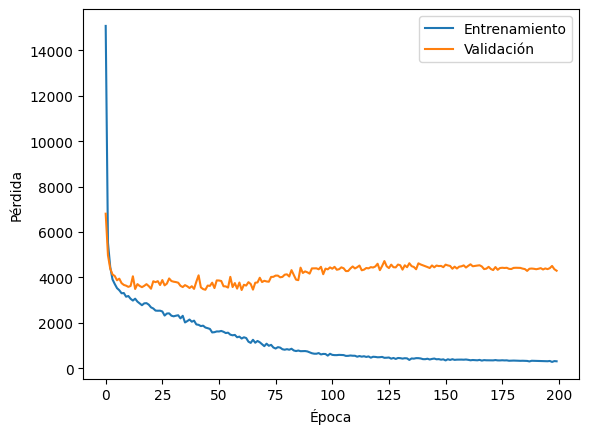

In [24]:
modelo = MiMLP(X_ent.shape[-1])
modelo.to(disp)

ecm = nn.MSELoss()
opt = SGD(modelo.parameters(), lr = 1e-3)
hist = entrena(modelo, ecm, nn.functional.mse_loss, opt,
               entdl, valdl, n_epocas=200)

plt.plot(hist['perdida_ent'], label='Entrenamiento')
plt.plot(hist['perdida_val'], label='Validación')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.show()

## Listas de instancias con `ModuleList`
Es posible trabajar con listas de instancias de `Module` en la definición de una subclase de `Module`. Sin embargo, es necesario hacerlo mediante la clase `ModuleList` para que puedan ser visibles para las demás instancias, funciones y herramientas de PyTorch. A diferencia de `Sequential`, no se presupone que las capas de una lista de `ModuleList` están conectadas secuencialmente. En cambio, esto se define dentro del método `forward`, como para cualquier otra capa. La red anterior se podría definir con `ModuleList` como:

In [25]:
class MLPModList(nn.Module):
  def __init__(self, d_ent):
    super().__init__()

    self.cod = nn.ModuleList([nn.Linear(d_ent, 20), nn.Linear(20, 30)])
    self.salida = nn.Linear(30, 1)

  def forward(self, x):
    for c in self.cod:
      x = th.sigmoid(c(x))
    return self.salida(x)

Instanciamos esta subclase, la movemos a la GPU, creamos el criterio de ECM, instanciamos el optimizador, entrenamos la red y graficamos la pérdida.

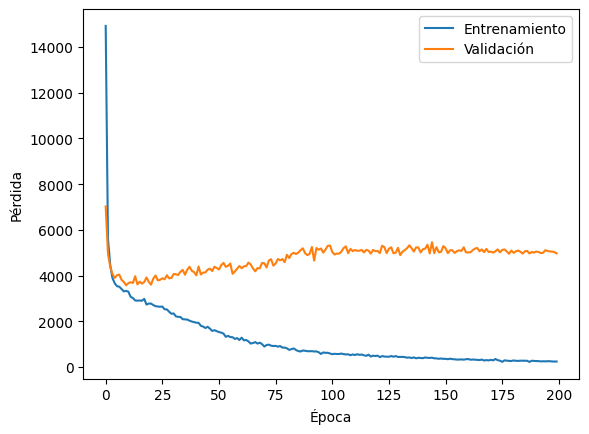

In [26]:
modelo = MLPModList(X_ent.shape[-1])
modelo.to(disp)

ecm = nn.MSELoss()
opt = SGD(modelo.parameters(), lr = 1e-3)
hist = entrena(modelo, ecm, nn.functional.mse_loss, opt,
               entdl, valdl, n_epocas=200)

plt.plot(hist['perdida_ent'], label='Entrenamiento')
plt.plot(hist['perdida_val'], label='Validación')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.show()